In [ ]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt

from tsfresh import (
    extract_features,  
    select_features
)
from tsfresh.utilities.dataframe_functions import impute

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

import gc

39

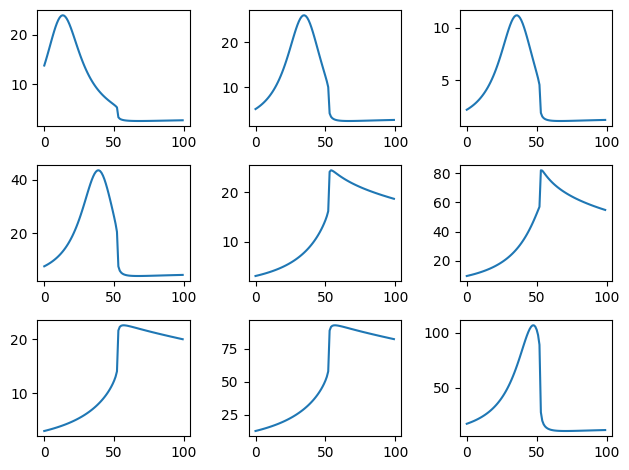

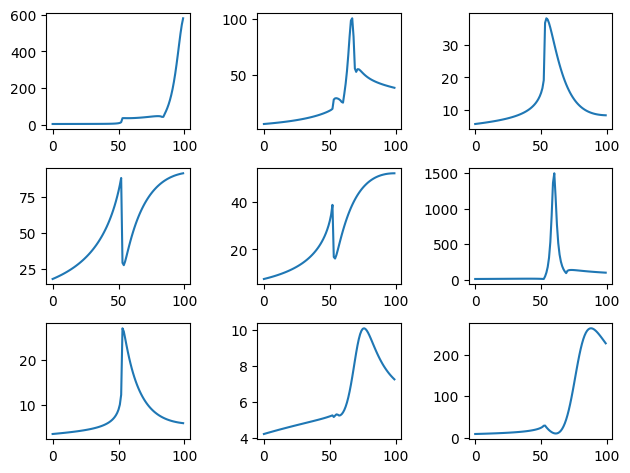

In [ ]:
features_0 = np.array(np.load("data/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("data/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("data/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("data/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("data/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("data/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("data/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("data/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

label_arr = np.array([np.tile(i,features_0.shape[0]) for i in np.arange(0,8)]).flatten()


fig,axs = plt.subplots(3,3)
axs = axs.flatten()
for i in range(9):
    axs[i].plot(features_0[i])
fig.tight_layout()

fig,axs = plt.subplots(3,3)
axs = axs.flatten()
for i in range(9):
    axs[i].plot(features_7[i])
fig.tight_layout()
gc.collect()

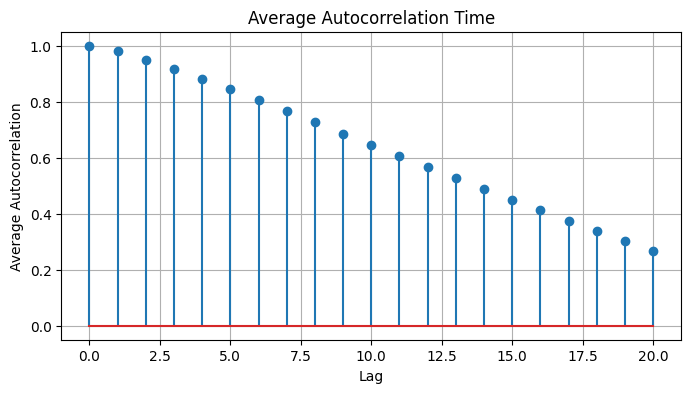

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Example dataset: Replace with your own array data
# Each row represents a separate time series

# Define the maximum lag to consider
max_lag = 20

def autocorrelation(x, lag):
    """
    Calculate the autocorrelation of a 1D array x at a specific lag.
    """
    n = len(x)
    x_mean = np.mean(x)
    c0 = np.sum((x - x_mean) ** 2) / n
    
    return np.sum((x[:n - lag] - x_mean) * (x[lag:] - x_mean)) / (n - lag) / c0

# Calculate autocorrelation for each series and lag
acf_values = np.zeros((all_features.shape[0], max_lag + 1))
for i, series in enumerate(all_features):
    for lag in range(max_lag + 1):
        acf_values[i, lag] = autocorrelation(series, lag)

# Compute the average autocorrelation across all series
avg_acf = np.mean(acf_values, axis=0)

# Plot the average autocorrelation
plt.figure(figsize=(8, 4))
plt.stem(range(max_lag + 1), avg_acf)
plt.xlabel('Lag')
plt.ylabel('Average Autocorrelation')
plt.title('Average Autocorrelation Time')
plt.grid()
plt.show()


### idea: temporal correlation suggest treating the signal as a time series feature could result in increased prediction accuracy.
### first thing to check is extracting time series features and classifying based on that. 
### next step is to test if an RNN can extract a more performant representation on its own.

In [ ]:
data_df = pd.DataFrame()
labels_df = pd.Series()

data_df['id'] = np.repeat(np.arange(all_features.shape[0]),all_features.shape[1])
data_df['time'] = np.tile(np.arange(all_features.shape[1]), all_features.shape[0])
data_df['feature'] = all_features.flatten()
data_df.to_parquet('data/data_df.parquet')

labels_df['labels'] = label_arr

data_df

,id,time,feature
0,0,0,13.753024
1,0,1,14.674004
2,0,2,15.638559
3,0,3,16.635180
4,0,4,17.650384
...,...,...,...
2399995,23999,95,222.277109
2399996,23999,96,237.572621
2399997,23999,97,248.774345
2399998,23999,98,255.216699


In [4]:
gc.collect()
# Load data once
dask_df = dd.read_parquet('data/data_df.parquet')

# Extract features
extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=-1,disable_progressbar=False,).compute()

# Handle any NaNs
impute(extracted_features)

# Convert labels to a Series (ensure it’s 1D if needed)
labels_series =  pd.Series(np.array(labels_df.to_numpy()[0]))

# Select relevant features
features_filtered = select_features(extracted_features, labels_series, multiclass=True)

# Save to a .npy file with memory-mapping enabled
np.save('data/features_filtered.npy', features_filtered.to_numpy())
gc.collect()

0

In [7]:
features_filtered

variable,feature__abs_energy,feature__absolute_maximum,feature__absolute_sum_of_changes,"feature__agg_autocorrelation__f_agg_""mean""__maxlag_40","feature__agg_autocorrelation__f_agg_""median""__maxlag_40","feature__agg_autocorrelation__f_agg_""var""__maxlag_40","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""",...,feature__symmetry_looking__r_0.2,feature__symmetry_looking__r_0.25,feature__symmetry_looking__r_0.30000000000000004,feature__symmetry_looking__r_0.35000000000000003,feature__time_reversal_asymmetry_statistic__lag_1,feature__time_reversal_asymmetry_statistic__lag_2,feature__time_reversal_asymmetry_statistic__lag_3,feature__variance,feature__variance_larger_than_standard_deviation,feature__variation_coefficient
id,,,,,,,,,,,,,,,,,,,,,
0,1.366759e+04,23.918039,31.698840,0.408902,0.418089,0.179896,22.663595,19.392079,16.016531,4.614539,...,1.0,1.0,1.0,1.0,-3.878319e+01,-9.674395e+01,-1.801483e+02,5.614541e+01,1.0,0.834981
1,1.553016e+04,25.935394,44.349551,0.138619,0.074365,0.325454,19.810890,16.191011,13.033462,5.346711,...,1.0,1.0,1.0,1.0,-1.048901e+00,-1.755551e+00,-2.157074e+00,6.528598e+01,1.0,0.851630
2,2.867975e+03,11.203798,19.230939,0.122892,0.049879,0.329015,8.378110,6.836979,5.446893,1.000022,...,1.0,1.0,1.0,1.0,-5.714397e-02,-6.180030e-02,-1.101976e-02,1.215478e+01,1.0,0.857636
3,4.167144e+04,43.422934,75.172240,0.084176,-0.009626,0.331067,30.626780,24.822289,19.408847,15.725694,...,1.0,1.0,1.0,1.0,1.750517e+00,1.199543e+01,3.180206e+01,1.808109e+02,1.0,0.875478
4,2.441234e+04,24.419825,27.135719,0.437924,0.510050,0.175845,4.322164,3.217947,1.941413,1.629511,...,1.0,1.0,1.0,1.0,8.680670e+01,1.785913e+02,2.759930e+02,5.801085e+01,1.0,0.558299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,6.594488e+03,20.485598,33.966174,-0.019661,-0.130338,0.296096,6.455342,5.681841,4.762355,1.355783,...,1.0,1.0,1.0,1.0,-1.514639e+00,-4.393932e+00,-7.792146e+00,1.869634e+01,1.0,0.629048
23996,1.860261e+05,111.959244,194.775368,0.013142,-0.050119,0.314281,30.655608,26.376577,21.757634,35.282181,...,1.0,1.0,1.0,1.0,-2.904348e+02,-7.350359e+02,-1.220344e+03,5.782400e+02,1.0,0.671593
23997,1.874118e+08,3321.007136,3999.064222,0.314733,0.251929,0.162396,-787.220459,-697.623596,-565.222770,-26745.286310,...,0.0,1.0,1.0,1.0,2.688172e+08,6.349339e+08,1.096198e+09,1.276319e+06,1.0,1.461175


In [8]:
# Later, load the saved array in memory-mapped mode
features_memmap = np.load('data/features_filtered.npy', mmap_mode='r+')

### tune hyperparameters

In [24]:
import numpy as np
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Train-test split
X_train_old, X_test_old, y_train, y_test = train_test_split(all_features, label_arr, test_size=0.1, random_state=42)
X_train_new, X_test_new, _, _ = train_test_split(features_memmap, label_arr, test_size=0.1, random_state=42)


# Define the model
model = HistGradientBoostingClassifier()

# Define the parameter grid with a large search space
param_grid = {
    'learning_rate': np.logspace(-3, 0, 10),     # Learning rates between 0.001 and 1
    'max_iter': [50, 100, 200, 300],             # Number of boosting iterations
    'max_leaf_nodes': [10, 20, 31, 50, 100],     # Number of leaves in trees
    'min_samples_leaf': [10, 20, 30, 50, 100],   # Minimum samples per leaf
    'l2_regularization': np.logspace(-3, 1, 5)   # Regularization strength
}

# Define the halving search with cross-validation
halving_search = HalvingRandomSearchCV(
    estimator=model,
    param_distributions=param_grid,
    factor=2,                       # Halving factor (reduces candidate space by half each iteration)
    cv=5,                           # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1                       # Use all available CPU cores
)

# Perform the halving search
halving_search.fit(X_train_new, y_train)

# Print the best parameters and score
print("Best parameters found: ", halving_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(halving_search.best_score_))

# Evaluate the best model on the test set
best_model = halving_search.best_estimator_
test_accuracy = accuracy_score(y_test, best_model.predict(X_test_new))
print("Test accuracy: {:.2f}".format(test_accuracy))


KeyboardInterrupt: 

In [23]:
X_train_new.shape

(21600, 530)

In [ ]:
# Initialize the model
model_old = HistGradientBoostingClassifier(random_state=42)
model_new = HistGradientBoostingClassifier(random_state=42)

In [ ]:


# Initialize the model
model_old = HistGradientBoostingClassifier(random_state=42)
model_new = HistGradientBoostingClassifier(random_state=42)


cv_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='accuracy', return_estimator=True)
cv_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='accuracy', return_estimator=True)

In [ ]:
rmse = cv_old["test_score"]
print(f"Validation Accuracy Old Data = {rmse.mean():.3f} +/- {rmse.std():.3f}")

rmse = cv_new["test_score"]
print(f"Validation Accuracy New Data = {rmse.mean():.3f} +/- {rmse.std():.3f}")

Validation Accuracy Old Data = 0.804 +/- 0.004
Validation Accuracy New Data = 0.934 +/- 0.003


In [13]:
old_test_arr = np.zeros(5)
new_test_arr = np.zeros(5)

for cnt,est in enumerate(cv_old["estimator"]):
    old_test_arr[cnt] = accuracy_score(y_test, est.predict(X_test_old))

for cnt,est in enumerate(cv_new["estimator"]):
    new_test_arr[cnt] = accuracy_score(y_test, est.predict(X_test_new))

print(f"Old Dataset - Test Accuracy: {np.mean(old_test_arr):.4f} ± {np.std(old_test_arr):.4f}")
print(f"New Dataset - Test Accuracy: {np.mean(new_test_arr):.4f} ± {np.std(new_test_arr):.4f}")

Old Dataset - Test Accuracy: 0.7977 ± 0.0036
New Dataset - Test Accuracy: 0.9298 ± 0.0040


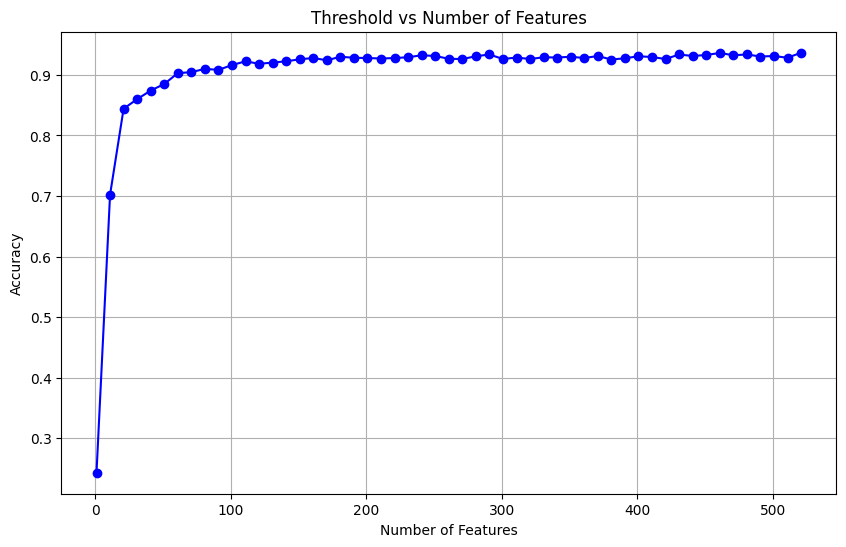

Best Threshold: 521.0000
Best Accuracy: 0.9367
Number of Features: 521


In [ ]:

# Define a range of thresholds to test
thresholds = np.arange(1, X_train_new.shape[1], 10)  # 50 thresholds between 0 and 0.5
accuracies = []
num_features_list = []

best_accuracy = 0
best_threshold = 0
best_num_features = X_train_new.shape[1]

for threshold in thresholds:
    selector = SelectKBest(f_classif, k=int(threshold))
    X_train_selected = selector.fit_transform(X_train_new, y_train)
    X_test_selected = selector.transform(X_test_new)
    
    # Initialize and fit a HistGradientBoostingClassifier with isotonic calibration
    hgb_classifier = HistGradientBoostingClassifier(random_state=42)
    hgb_classifier.fit(X_train_selected, y_train)
    
    # Evaluate accuracy
    y_pred = hgb_classifier.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Keep track of accuracy and number of features
    num_features = X_train_selected.shape[1]
    accuracies.append(accuracy)
    num_features_list.append(num_features)
    
    # Keep track of the best threshold based on accuracy and feature count
    if accuracy > best_accuracy or (accuracy == best_accuracy and num_features < best_num_features):
        best_accuracy = accuracy
        best_threshold = threshold
        best_num_features = num_features

# Plot threshold vs number of features
plt.figure(figsize=(10, 6))
plt.plot(num_features_list, accuracies, label="Number of Features", color='blue', marker='o')
plt.ylabel("Accuracy")
plt.xlabel("Number of Features")
plt.title("Threshold vs Number of Features")
plt.grid(True)

plt.show()

# Print the best threshold and accuracy information
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Number of Features: {best_num_features}")


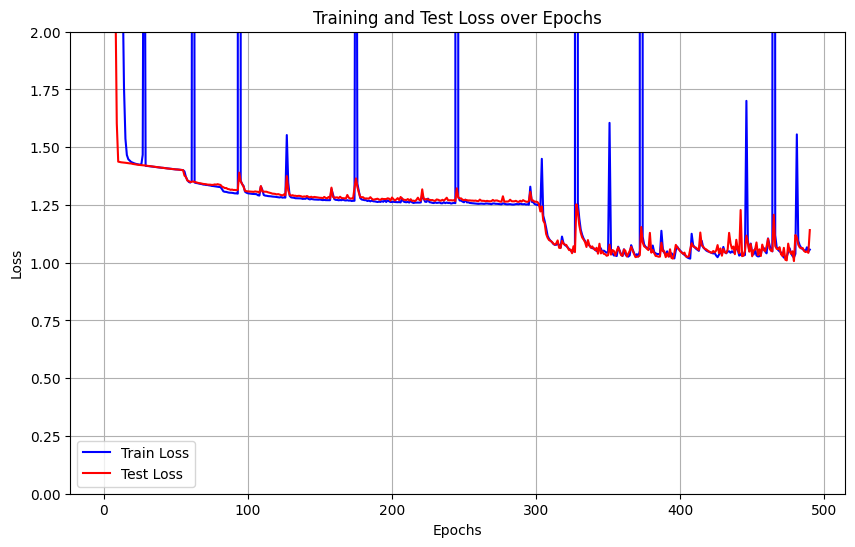

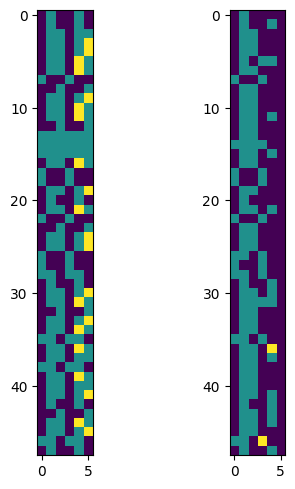

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 0., 1., 1., 0.],
       [0., 1., 1., 0., 0., 0.],
       [1., 0., 0., 1., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 1., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0.],
       [0., 1., 1., 0., 1., 0.],
       [0., 1., 1., 0., 0., 0.],
       [1., 0., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0., 0.],
       [1., 1., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0., 0.],
       [1., 1., 0., 1., 0., 0.],
       [0., 1., 0., 0., 1., 0.],
       [0.

0.0 1.0 0.0 0.0 0.0 0.0 1
0.0 1.0 0.0 0.0 1.0 0.0 -1
0.0 1.0 1.0 0.0 0.0 0.0 -1
1.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 0.0 5
0.0 1.0 1.0 0.0 1.0 0.0 5
0.0 1.0 0.0 0.0 0.0 0.0 1
1.0 0.0 0.0 1.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 0.0 5
0.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 1.0 -1
0.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 0.0 5
1.0 1.0 1.0 1.0 1.0 0.0 6
1.0 1.0 1.0 1.0 1.0 0.0 6
0.0 1.0 1.0 0.0 1.0 1.0 -1
1.0 0.0 0.0 1.0 0.0 0.0 -1
1.0 0.0 0.0 1.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 1.0 -1
0.0 1.0 0.0 0.0 0.0 0.0 1
0.0 1.0 1.0 0.0 1.0 1.0 -1
1.0 0.0 0.0 1.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 1.0 -1
0.0 1.0 1.0 0.0 1.0 0.0 5
1.0 1.0 0.0 1.0 0.0 0.0 3
1.0 0.0 0.0 1.0 0.0 0.0 -1
1.0 1.0 0.0 1.0 1.0 0.0 -1
0.0 1.0 0.0 0.0 1.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 0.0 5
0.0 1.0 1.0 0.0 1.0 0.0 5
0.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 1.0 -1
0.0 1.0 1.0 0.0 0.0 0.0 -1
1.0 1.0 1.0 0.0 0.0 0.0 -1
0.0 1.0 1.0 0.0 1.0 0.0 5
0.0 1.0 1.0 0.0